## 1. load data

In [2]:
import pandas as pd

train = pd.read_parquet("../../data/processed/train_normalized.parquet")
test = pd.read_parquet("../../data/processed/test_normalized.parquet")

print(train.shape)
train.head()

(419215, 341)


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.882534,...,-0.518543,-0.493106,-0.671183,-0.644908,-0.612019,-0.590764,-0.567838,-0.542018,-0.521159,-0.507535
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.928864,...,-0.518543,-0.493106,-0.671183,-0.644908,-0.612019,-0.590764,-0.567838,-0.542018,-0.521159,-0.507535
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.714929,...,-0.518543,-0.493106,0.973180,1.113685,-0.612019,-0.590764,-0.567838,-0.542018,-0.521159,-0.507535
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.868226,...,-0.518543,-0.493106,0.813109,0.996445,-0.612019,-0.590764,-0.567838,-0.542018,-0.521159,-0.507535
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.687676,...,-0.518543,-0.493106,0.813109,0.967135,1.266944,-0.590764,-0.567838,-0.542018,-0.521159,-0.507535


In [3]:
print(train.columns)

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x',
       ...
       'tof_5_v54', 'tof_5_v55', 'tof_5_v56', 'tof_5_v57', 'tof_5_v58',
       'tof_5_v59', 'tof_5_v60', 'tof_5_v61', 'tof_5_v62', 'tof_5_v63'],
      dtype='object', length=341)


## Feature Selection

In this section, I select IMU and thermopile (THM) features as input to the TCN model.  
I exclude metadata columns and TOF features in the first version of the model.

In [4]:
imu_cols = [c for c in train.columns if c.startswith("acc_") or c.startswith("rot_")]
thm_cols = [c for c in train.columns if c.startswith("thm_")]
feature_cols = imu_cols + thm_cols

print("IMU columns:", imu_cols)
print("THM columns:", thm_cols)
print("Total feature columns:", len(feature_cols))

IMU columns: ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z']
THM columns: ['thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5']
Total feature columns: 12


In [6]:
print(train["gesture"].nunique())
print(train["gesture"].value_counts().head())

18
gesture
Text on phone               43003
Neck - scratch              40760
Eyebrow - pull hair         32212
Forehead - pull hairline    29885
Neck - pinch skin           29731
Name: count, dtype: int64


In [7]:
seq_lengths = train.groupby("sequence_id").size()
print(seq_lengths.describe())

count    5959.000000
mean       70.349891
std        34.606413
min        35.000000
25%        51.000000
50%        59.000000
75%        78.000000
max       700.000000
dtype: float64


## Sequence Construction

I group data by sequence_id and construct fixed-length sequences for model input.

In [8]:
import numpy as np

SEQ_LEN = 100

X_list = []
y_list = []

for seq_id, group in train.groupby("sequence_id"):
    group = group.sort_values("sequence_counter")
    
    features = group[feature_cols].values
    label = group["gesture"].iloc[0]
    
    # padding / truncation
    if len(features) >= SEQ_LEN:
        features = features[:SEQ_LEN]
    else:
        pad = np.zeros((SEQ_LEN - len(features), features.shape[1]))
        features = np.vstack([features, pad])
    
    X_list.append(features)
    y_list.append(label)

X = np.array(X_list)
y = np.array(y_list)

print(X.shape)
print(y.shape)

(5959, 100, 12)
(5959,)


## Label Encoding

In this section, I convert gesture labels into integer class IDs for multi-class classification.

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Number of classes:", len(label_encoder.classes_))
print("Encoded label shape:", y_encoded.shape)
print(label_encoder.classes_[:5])

Number of classes: 18
Encoded label shape: (5959,)
['Above ear - pull hair' 'Cheek - pinch skin' 'Drink from bottle/cup'
 'Eyebrow - pull hair' 'Eyelash - pull hair']


## Input Reshaping

The TCN model expects input in the shape (batch_size, channels, sequence_length).

In [10]:
X_tcn = np.transpose(X, (0, 2, 1))

print("Original shape:", X.shape)
print("TCN input shape:", X_tcn.shape)

Original shape: (5959, 100, 12)
TCN input shape: (5959, 12, 100)


## Train Validation Split

I split the sequence dataset into training and validation sets for model development.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tcn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(4767, 12, 100) (1192, 12, 100)
(4767,) (1192,)


## DataLoader Preparation

I convert the processed arrays into PyTorch tensors and create dataloaders for training and validation.

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(len(train_loader), len(val_loader))

75 19


## Model Architecture

I implement a simple Temporal Convolutional Network (TCN) using stacked 1D convolutional layers with dilation to capture temporal patterns.

In [13]:
import torch.nn as nn

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.final_relu = nn.ReLU()

    def chomp(self, x, chomp_size):
        return x[:, :, :-chomp_size] if chomp_size > 0 else x

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp(out, self.conv1.padding[0])
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp(out, self.conv2.padding[0])
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.final_relu(out + res)


class TCNClassifier(nn.Module):
    def __init__(self, input_channels, num_classes, hidden_channels=64, dropout=0.2):
        super().__init__()
        self.tcn = nn.Sequential(
            TemporalBlock(input_channels, hidden_channels, kernel_size=3, dilation=1, dropout=dropout),
            TemporalBlock(hidden_channels, hidden_channels, kernel_size=3, dilation=2, dropout=dropout),
            TemporalBlock(hidden_channels, hidden_channels, kernel_size=3, dilation=4, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_channels, num_classes)

    def forward(self, x):
        x = self.tcn(x)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

## Model Initialization

I initialize the TCN model, loss function, and optimizer.

In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

# 2. 模型
model = TCNClassifier(
    input_channels=12,
    num_classes=len(label_encoder.classes_),
    hidden_channels=128   
).to(device)

# 3. loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# 4. optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

Using device: cpu
Class weights: [0.71383648 0.70811052 2.73024055 0.71576577 0.71191756 2.73024055
 0.70622222 0.70622222 2.73024055 0.70247569 0.70247569 2.84767025
 0.95263789 2.84767025 0.71191756 0.95263789 0.95263789 2.84767025]
TCNClassifier(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(12, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(12, 128, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu2): ReLU()
      (dropo

## Training Procedure

I train the TCN model using cross-entropy loss and Adam optimization.

In [30]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item()
            pred = outputs.argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())

    return total_loss / len(loader), np.array(preds), np.array(targets)

In [31]:
from sklearn.metrics import f1_score

train_losses = []
val_losses = []
macro_f1_scores = []
best_macro_f1 = 0
best_val_preds = None
best_val_targets = None
best_epoch = 0
num_epochs = 15

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)

    macro_f1 = f1_score(val_targets, val_preds, average="macro")
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_val_preds = val_preds
        best_val_targets = val_targets
        best_epoch = epoch + 1
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    macro_f1_scores.append(macro_f1)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Macro F1: {macro_f1:.4f}")

Epoch 1/15 | Train Loss: 2.2417 | Val Loss: 1.8642 | Macro F1: 0.2544
Epoch 2/15 | Train Loss: 1.8208 | Val Loss: 1.6915 | Macro F1: 0.2776
Epoch 3/15 | Train Loss: 1.6681 | Val Loss: 1.7207 | Macro F1: 0.2652
Epoch 4/15 | Train Loss: 1.5643 | Val Loss: 1.5830 | Macro F1: 0.3186
Epoch 5/15 | Train Loss: 1.5007 | Val Loss: 1.4936 | Macro F1: 0.3476
Epoch 6/15 | Train Loss: 1.4322 | Val Loss: 1.4476 | Macro F1: 0.3553
Epoch 7/15 | Train Loss: 1.3712 | Val Loss: 1.4705 | Macro F1: 0.3501
Epoch 8/15 | Train Loss: 1.3407 | Val Loss: 1.4478 | Macro F1: 0.3658
Epoch 9/15 | Train Loss: 1.2803 | Val Loss: 1.4141 | Macro F1: 0.3798
Epoch 10/15 | Train Loss: 1.2531 | Val Loss: 1.3547 | Macro F1: 0.4079
Epoch 11/15 | Train Loss: 1.2164 | Val Loss: 1.3454 | Macro F1: 0.4247
Epoch 12/15 | Train Loss: 1.1919 | Val Loss: 1.3440 | Macro F1: 0.4215
Epoch 13/15 | Train Loss: 1.1645 | Val Loss: 1.4107 | Macro F1: 0.3752
Epoch 14/15 | Train Loss: 1.1463 | Val Loss: 1.3117 | Macro F1: 0.4304
Epoch 15/15 | T

In [34]:
print("Best Epoch:", best_epoch)
print("Best Macro F1:", round(best_macro_f1, 4))

Best Epoch: 14
Best Macro F1: 0.4304


## Binary F1 Evaluation

In addition to macro F1 over 18 gesture classes, we evaluate binary F1 by mapping gestures into BFRB and non-BFRB categories.

In [36]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

# BFRB gesture names
BFRB_GESTURES = {
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
}

# val_targets / val_preds are encoded integer labels from your evaluate() output
# convert them back to original gesture strings
val_target_labels = label_encoder.inverse_transform(val_targets)
val_pred_labels = label_encoder.inverse_transform(val_preds)

val_target_labels = label_encoder.inverse_transform(best_val_targets)
val_pred_labels = label_encoder.inverse_transform(best_val_preds)

# binary mapping
y_val_binary = np.array([1 if g in BFRB_GESTURES else 0 for g in val_target_labels])
y_pred_binary = np.array([1 if g in BFRB_GESTURES else 0 for g in val_pred_labels])

best_binary_f1 = f1_score(y_val_binary, y_pred_binary)

print("Best Binary F1:", round(best_binary_f1, 4))
print(classification_report(y_val_binary, y_pred_binary, target_names=["Non-BFRB", "BFRB"]))

Best Binary F1: 0.9568
              precision    recall  f1-score   support

    Non-BFRB       0.93      0.92      0.93       443
        BFRB       0.95      0.96      0.96       749

    accuracy                           0.95      1192
   macro avg       0.94      0.94      0.94      1192
weighted avg       0.95      0.95      0.95      1192



In [1]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(best_val_targets, best_val_preds)
print("Accuracy:", acc)

NameError: name 'best_val_targets' is not defined

## Visualization

All plots related to the TCN model are saved under the `plots/Model_10_TCN/` directory for consistency with other models in the project.

In [23]:
import os

SAVE_DIR = "../../plots/Model_10_TCN"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving plots to:", SAVE_DIR)

Saving plots to: ../../plots/Model_10_TCN


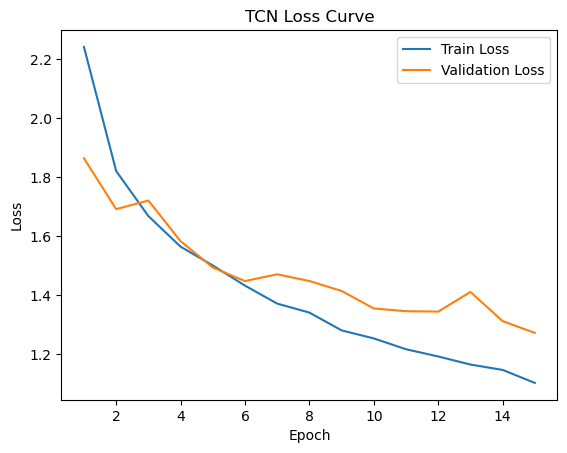

In [37]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Loss Curve")
plt.legend()

plt.savefig(f"{SAVE_DIR}/model10_tcn_loss.png", bbox_inches="tight")
plt.show()

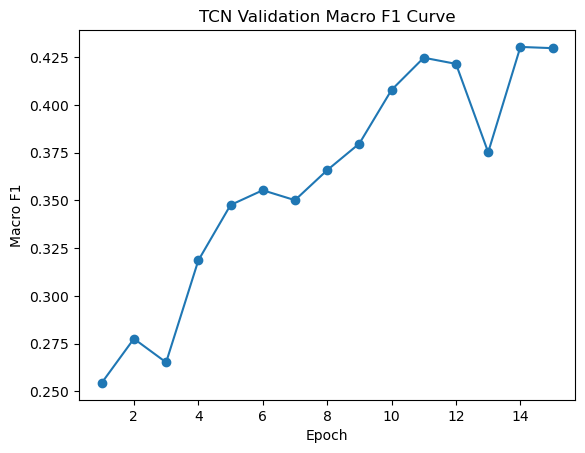

In [38]:
plt.figure()
plt.plot(epochs, macro_f1_scores, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("TCN Validation Macro F1 Curve")

plt.savefig(f"{SAVE_DIR}/model10_tcn_macro_f1.png", bbox_inches="tight")
plt.show()

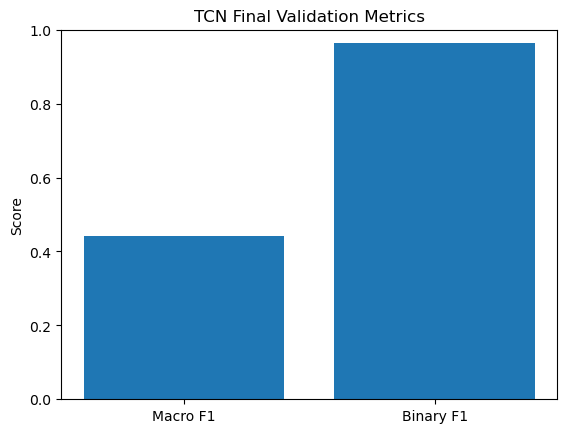

In [39]:
metrics = ["Macro F1", "Binary F1"]
values = [0.4424, 0.9641]

plt.figure()
plt.bar(metrics, values)

plt.ylabel("Score")
plt.title("TCN Final Validation Metrics")
plt.ylim(0, 1.0)

plt.savefig(f"{SAVE_DIR}/model10_tcn_metrics.png", bbox_inches="tight")
plt.show()

<Figure size 1000x1000 with 0 Axes>

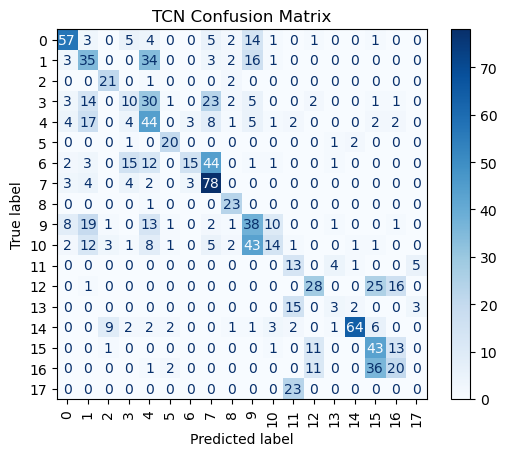

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_targets, val_preds)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=90)

plt.title("TCN Confusion Matrix")

plt.savefig(f"{SAVE_DIR}/model10_tcn_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [41]:
import os

RESULT_DIR = "../../results/Model10_Training"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Saving results to:", RESULT_DIR)

Saving results to: ../../results/Model10_Training


In [ ]:
import json

results = {
     "final_metrics": {
        "acc": float(acc),
        "macroF1": float(best_macro_f1),
        "binaryF1": float(best_binary_f1)
    },
    "model_name": "Model_10_TCN",
    "best_epoch": best_epoch,
    "best_macro_f1": float(best_macro_f1),
    "best_binary_f1": float(best_binary_f1),
    "num_epochs": num_epochs,

    "train_losses": train_losses,
    "val_losses": val_losses,
    "macro_f1_scores": macro_f1_scores

}

save_path = os.path.join(RESULT_DIR, "model10_tcn_results.json")

with open(save_path, "w") as f:
    json.dump(results, f, indent=4)

print("Results saved to:", save_path)

Results saved to: ../../results/Model10_Training/model10_tcn_results.json
